**Optimizing DFW Operations: A Data-Driven Analysis of Flight Delays**
---------------------------------------------------------------------------
This analysis investigates flight delay bottlenecks at the DFW hub. By querying over 100,000 synthetic flight records using SQL and Python, the goal is to identify which operational factors (weather, maintenance, ATC) drive the most delays, providing data-driven insights for route optimization.

In [ ]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect('aviation_operations.db')

# Load the CSV file into a pandas DataFrame
file_path = 'flight_delays.csv' 
df = pd.read_csv(file_path)

# Writing the data directly to a new SQL table called 'real_flights'
df.to_sql('real_flights', conn, if_exists='replace', index=False)

print("Dataset successfully loaded into the database!")

Dataset successfully loaded into the database!


In [9]:
# Query the database to check the first 5 rows
test_query = "SELECT * FROM real_flights LIMIT 5"
test_results = pd.read_sql(test_query, conn)

print(test_results)

   FlightID    Airline  FlightNumber Origin Destination ScheduledDeparture  \
0         1     United          4558    ORD         MIA   2024-09-01 08:11   
1         2      Delta          8021    LAX         MIA   2024-09-01 10:25   
2         3  Southwest          7520    DFW         SFO   2024-09-01 16:53   
3         4      Delta          2046    ORD         BOS   2024-09-01 14:44   
4         5      Delta          6049    LAX         SEA   2024-09-01 01:51   

    ActualDeparture  ScheduledArrival     ActualArrival  DelayMinutes  \
0  2024-09-01 08:30  2024-09-01 12:11  2024-09-01 12:19             8   
1  2024-09-01 10:41  2024-09-01 13:25  2024-09-01 13:27             2   
2  2024-09-01 17:05  2024-09-01 17:53  2024-09-01 18:07            14   
3  2024-09-01 15:04  2024-09-01 18:44  2024-09-01 18:34           -10   
4  2024-09-01 02:08  2024-09-01 05:51  2024-09-01 06:15            24   

           DelayReason  Cancelled  Diverted AircraftType TailNumber  Distance  
0           

In [ ]:
# 1. Defining the SQL query
analyst_query = """
SELECT 
    DelayReason, 
    COUNT(FlightID) AS Total_Delays, 
    AVG(DelayMinutes) AS Average_Delay_Time
FROM real_flights
WHERE Airline = 'American Airlines' AND Origin = 'DFW' AND DelayMinutes > 0
GROUP BY DelayReason
ORDER BY Total_Delays DESC;
"""

# 2. Running the query and store the results in a pandas DataFrame
insights_df = pd.read_sql(analyst_query, conn)

# 3. Displaying the results
print(insights_df)

           DelayReason  Total_Delays  Average_Delay_Time
0          Maintenance         21449           15.578675
1              Weather         21223           15.531734
2  Air Traffic Control         20944           15.492838


In [ ]:
# CTE Query: Compare DFW average delay to the overall airline average
cte_query = """
WITH OverallAvg AS (
    SELECT AVG(DelayMinutes) AS National_Avg_Delay
    FROM real_flights
    WHERE Airline = 'American Airlines' AND DelayMinutes > 0
)
SELECT 
    Origin,
    AVG(DelayMinutes) AS Hub_Avg_Delay,
    (SELECT National_Avg_Delay FROM OverallAvg) AS National_Avg_Delay,
    AVG(DelayMinutes) - (SELECT National_Avg_Delay FROM OverallAvg) AS Difference_From_National
FROM real_flights
WHERE Airline = 'American Airlines' AND Origin = 'DFW' AND DelayMinutes > 0
GROUP BY Origin;
"""

cte_df = pd.read_sql(cte_query, conn)
print("--- DFW vs National Delay Average ---")
print(cte_df)

--- DFW vs National Delay Average ---
  Origin  Hub_Avg_Delay  National_Avg_Delay  Difference_From_National
0    DFW      15.534755           15.503347                  0.031408


In [ ]:
# Window Function Query: Rank the worst destinations for delays out of DFW
window_query = """
SELECT 
    Destination, 
    COUNT(FlightID) AS Total_Flights,
    AVG(DelayMinutes) AS Avg_Delay,
    RANK() OVER(ORDER BY AVG(DelayMinutes) DESC) as Delay_Rank
FROM real_flights
WHERE Airline = 'American Airlines' AND Origin = 'DFW' AND DelayMinutes > 0
GROUP BY Destination
LIMIT 10;
"""

# Executing the query and display the ranking
ranking_df = pd.read_sql(window_query, conn)
print("\n--- Top 10 Worst Destinations for Delays from DFW ---")
print(ranking_df)


--- Top 10 Worst Destinations for Delays from DFW ---
  Destination  Total_Flights  Avg_Delay  Delay_Rank
0         BOS          12651  15.607936           1
1         SFO          12831  15.602369           2
2         JFK          12700  15.541890           3
3         MIA          12806  15.473138           4
4         SEA          12628  15.448052           5


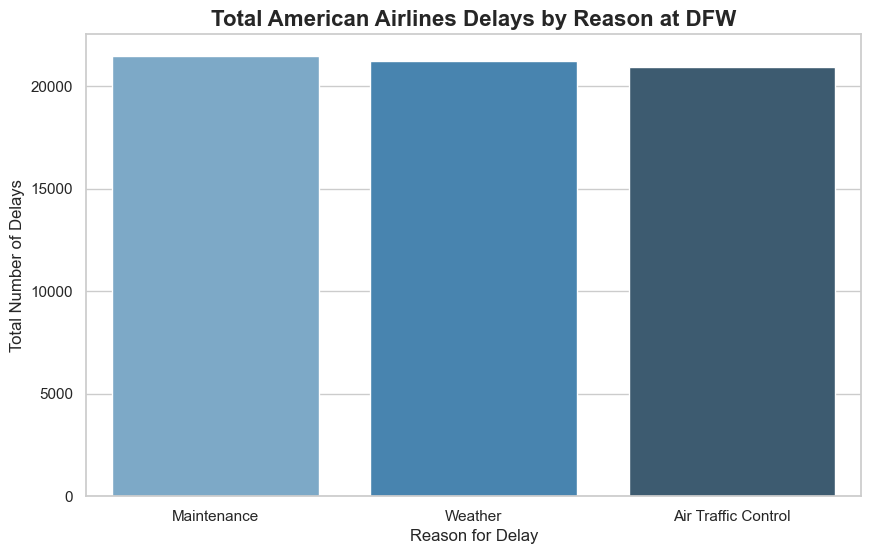

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid")

# Creating the bar chart using the insights_df from the first query
plt.figure(figsize=(10, 6))
chart = sns.barplot(
    data=insights_df, 
    x='DelayReason', 
    y='Total_Delays', 
    hue='DelayReason',
    legend=False,
    palette="Blues_d" 
)

# Adding titles and labels
plt.title('Total American Airlines Delays by Reason at DFW', fontsize=16, fontweight='bold')
plt.xlabel('Reason for Delay', fontsize=12)
plt.ylabel('Total Number of Delays', fontsize=12)

# Displaying the chart
plt.show()

The data reveals that DFW's delay distribution is highly uniform and operates identically to the national average (15.5 minutes). Because routine maintenance and uncontrollable weather contribute equally to these delays, next steps should include cross-referencing specific aircraft maintenance logs with seasonal weather patterns to find deeper operational efficiencies.